#### 1. Importing Dependencies

In [6]:
import warnings
warnings.filterwarnings("ignore")

import os
import shutil
import uuid
import numpy as np
import cv2 as cv
import random
import albumentations as A
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

#### 2. Loading Dataset Path and Images

In [7]:
images_path = os.path.join("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/images/")
labels_path = os.path.join("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/labels/")

#### 3. Data Albumentation to fulfill the lack of number of data

In [8]:
# pos_data_path = os.path.join("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/Positives/")
# neg_data_path = os.path.join("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/Negatives/")

# os.mkdir("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/Albumentations/")
# os.mkdir("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/Albumentations/Positives/")
# os.mkdir("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/Albumentations/Negatives/")

# pos_alb_path = "C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/Albumentations/Positives/"
# neg_alb_path = "C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/Albumentations/Negatives/"

In [9]:
transform = A.Compose(
    [
        A.CLAHE(),
        A.Transpose(p=0),
        A.Affine(rotate=(-5, 5), scale=0.9, shear=1, translate_percent=0.1, p=0.7),
        A.Blur(blur_limit=1, p=0.2),
        A.OpticalDistortion(),
        A.GridDistortion(),
        A.HueSaturationValue(),
        A.Morphological(p=0.5, scale=(1, 7), operation="erosion"),
    ],
    strict=True,
    seed=137,
)

def image_transform(image_path, save_path, num_epoch=3):
    for n in range(num_epoch):
        image_list = os.listdir(image_path)
        for i in image_list:
            name = i
            img = cv.cvtColor(cv.imread(image_path+i), cv.COLOR_BGR2RGB)
            t_image = transform(image=img)["image"]
            plt.imsave(save_path+str(uuid.uuid4())+".jpg", t_image)
            
# image_transform(pos_data_path, pos_alb_path, num_epoch=3)
# image_transform(neg_data_path, neg_alb_path, num_epoch=14)

#### 4. Put label on images and renaming file

In [10]:
# pos_imgs = os.listdir(pos_data_path)
# neg_imgs = os.listdir(neg_data_path)

# images_path = os.path.join("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/images/")
# images_list = os.listdir(images_path)

# labels_path = os.path.join("C:/Users/Sina/Desktop/HamrahTel/Handwritten/Dataset/labels/")
# labels_list = os.listdir(labels_path)

# for i in range(len(neg_imgs)):
#     if neg_imgs[i] in pos_imgs:
#         os.remove(neg_data_path+neg_imgs[i])
#         print(neg_imgs[i], "Deleted")

# for i in range(len(pos_imgs)):
#     name = pos_imgs[i].split(".")[0]
#     with open(labels_path+name+".txt", 'w') as f:
#         f.write("1")

# for i in range(len(images_list)):
#     name = images_list[i].split(".")[0]
#     src = images_path+images_list[i]
#     dst = images_path+name+".jpg"
#     os.rename(src, dst)

#### 5. Loading our Custom Dataset using Torch Dataset

In [19]:
class CheckDataset(Dataset):
    
    def __init__(self, img_path, lbl_path):
        self.img_path = img_path
        self.lbl_path = lbl_path
        self.img_list = sorted(os.listdir(img_path))
        self.lbl_list = sorted(os.listdir(lbl_path))
        
    def __len__(self):
        return(len(self.img_list))
    
    def __getitem__(self, idx):
        # Reading labels
        with open(self.lbl_path+self.lbl_list[idx], 'r') as f:
            lbl = f.read()
        
        # Converting label from string to integer
        lbl = int(lbl)
        
        # Reading images and converting them to gray scale
        img = cv.cvtColor(cv.imread(self.img_path+self.img_list[idx]), cv.COLOR_BGR2GRAY)
        
        # Pixel Normalization
        img = img/255.0
        
        # Converting image array to torch.tensor format
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        
        return img, lbl

#### 6. Loading and spliting our Data using Torch DataLoader and sklearn train_test splitter

In [20]:
dataset = CheckDataset(img_path=images_path, lbl_path=labels_path)
train_data, test_data = train_test_split(dataset, train_size=0.8, shuffle=True)

In [35]:
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=True)

# Testing out a batch of images with corresponding labels
for imgs, labels in train_loader:
    print(imgs.shape)
    print(labels)
    break

torch.Size([16, 1, 64, 256])
tensor([1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0])


#### 7. Building CNN network

In [58]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.model = nn.Sequential(

            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
            
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(16 * 4 * 16, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [59]:
from torchinfo import summary

model = CNN()

summary(model, input_size=(16, 1, 64, 256))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [16, 1]                   --
├─Sequential: 1-1                        [16, 1]                   --
│    └─Conv2d: 2-1                       [16, 64, 64, 256]         640
│    └─Conv2d: 2-2                       [16, 128, 64, 256]        73,856
│    └─MaxPool2d: 2-3                    [16, 128, 32, 128]        --
│    └─BatchNorm2d: 2-4                  [16, 128, 32, 128]        256
│    └─ReLU: 2-5                         [16, 128, 32, 128]        --
│    └─Conv2d: 2-6                       [16, 256, 32, 128]        295,168
│    └─MaxPool2d: 2-7                    [16, 256, 16, 64]         --
│    └─BatchNorm2d: 2-8                  [16, 256, 16, 64]         512
│    └─ReLU: 2-9                         [16, 256, 16, 64]         --
│    └─Conv2d: 2-10                      [16, 64, 16, 64]          147,520
│    └─MaxPool2d: 2-11                   [16, 64, 8, 32]           -

#### 8. Hyper-Parameters Tuning for Training the model

In [60]:
lr = 1e-3
epochs = 50
criterion = nn.BCELoss()
optimizer = optim.Adam(params=model.parameters(), lr=lr, weight_decay=1e-2)

#### 9. Training our CNN Model

In [64]:
best_test_loss = float("inf")

for epoch in range(50):

    # =========================
    # Training
    # =========================
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).float()

        # Forward
        outputs = model(images).squeeze(1)

        # Loss
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Loss
        train_loss += loss.item()

        # Accuracy
        predictions = (outputs >= 0.5).float()

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total


    # =========================
    # Testing
    # =========================
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images).squeeze(1)

            # Loss
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            # Accuracy
            predictions = (outputs >= 0.5).float()

            test_correct += (predictions == labels).sum().item()
            test_total += labels.size(0)

    test_loss /= len(test_loader)
    test_accuracy = test_correct / test_total


    # =========================
    # Save best model
    # =========================
    if test_loss < best_test_loss:

        best_test_loss = test_loss

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )


    # =========================
    # Print
    # =========================
    print(
        f"Epoch [{epoch+1}/50] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.4f}"
    )

Epoch [1/50] | Train Loss: 0.2858 | Train Acc: 0.8818 | Test Loss: 0.2653 | Test Acc: 0.8927
Epoch [2/50] | Train Loss: 0.2677 | Train Acc: 0.8911 | Test Loss: 0.2679 | Test Acc: 0.8911
Epoch [3/50] | Train Loss: 0.2504 | Train Acc: 0.8997 | Test Loss: 0.2474 | Test Acc: 0.9089
Epoch [4/50] | Train Loss: 0.2419 | Train Acc: 0.9030 | Test Loss: 0.2299 | Test Acc: 0.9081
Epoch [5/50] | Train Loss: 0.2314 | Train Acc: 0.9081 | Test Loss: 0.2504 | Test Acc: 0.9136
Epoch [6/50] | Train Loss: 0.2260 | Train Acc: 0.9112 | Test Loss: 0.2452 | Test Acc: 0.8994
Epoch [7/50] | Train Loss: 0.2170 | Train Acc: 0.9156 | Test Loss: 0.2220 | Test Acc: 0.9108
Epoch [8/50] | Train Loss: 0.2132 | Train Acc: 0.9171 | Test Loss: 0.2246 | Test Acc: 0.9122
Epoch [9/50] | Train Loss: 0.2088 | Train Acc: 0.9195 | Test Loss: 0.2292 | Test Acc: 0.9141
Epoch [10/50] | Train Loss: 0.2046 | Train Acc: 0.9207 | Test Loss: 0.2034 | Test Acc: 0.9214
Epoch [11/50] | Train Loss: 0.2032 | Train Acc: 0.9213 | Test Loss: 0

#### 10. Saving CNN Model Weights and Testing on a random data

In [65]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss.item()
}, "checkpoint.pth")

In [70]:
checkpoint = torch.load("checkpoint.pth")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

epoch = checkpoint["epoch"]
loss = checkpoint["loss"]

In [90]:
test_image = cv.cvtColor(cv.imread(r"C:\Users\Sina\Desktop\HamrahTel\Handwritten\test.jpg"), cv.COLOR_BGR2GRAY)
test_image = torch.tensor(test_image, dtype=torch.float32)

image = test_image.unsqueeze(0).unsqueeze(0)
image = image.to(device)

model.eval()

with torch.no_grad():
    output = model(image).squeeze()

print("Output:", output.item())

Output: 1.0


#### 11. Visualization of CNN Model Training Steps

In [98]:
import re
import matplotlib.pyplot as plt

log_file = r"C:\Users\Sina\Desktop\HamrahTel\Handwritten\logs.txt"

with open(log_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

epochs = []
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for line in lines:

    match = re.search(
        r"Epoch\s*\[(\d+/\d+)\]\s*\|\s*"
        r"Train Loss:\s*([\d.]+)\s*\|\s*"
        r"Train Acc:\s*([\d.]+)\s*\|\s*"
        r"Test Loss:\s*([\d.]+)\s*\|\s*"
        r"Test Acc:\s*([\d.]+)",
        line
    )

    if match:

        epoch = int(match.group(1).split("/")[0])
        train_loss = float(match.group(2))
        train_acc = float(match.group(3))
        test_loss = float(match.group(4))
        test_acc = float(match.group(5))

        epochs.append(epoch)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)


# -----------------------------
# Check
# -----------------------------

print("Number of epochs:", len(epochs))

print("\nEpochs:")
print(epochs)

print("\nTrain Loss:")
print(train_losses)

print("\nTrain Accuracy:")
print(train_accs)

print("\nTest Loss:")
print(test_losses)

print("\nTest Accuracy:")
print(test_accs)

Number of epochs: 50

Epochs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]

Train Loss:
[0.2858, 0.2677, 0.2504, 0.2419, 0.2314, 0.226, 0.217, 0.2132, 0.2088, 0.2046, 0.2032, 0.1954, 0.1991, 0.1932, 0.1923, 0.1915, 0.1871, 0.1886, 0.1878, 0.189, 0.1876, 0.189, 0.1861, 0.1882, 0.1828, 0.1823, 0.1809, 0.1804, 0.182, 0.181, 0.1805, 0.1802, 0.1789, 0.1821, 0.1769, 0.1793, 0.1764, 0.1778, 0.1753, 0.1763, 0.1743, 0.1716, 0.1724, 0.172, 0.1737, 0.1732, 0.1738, 0.1725, 0.1732, 0.1725]

Train Accuracy:
[0.8818, 0.8911, 0.8997, 0.903, 0.9081, 0.9112, 0.9156, 0.9171, 0.9195, 0.9207, 0.9213, 0.9255, 0.9231, 0.927, 0.9262, 0.926, 0.9272, 0.9285, 0.9295, 0.9287, 0.9276, 0.9269, 0.9289, 0.9293, 0.9314, 0.9314, 0.9303, 0.9317, 0.9314, 0.932, 0.9309, 0.9319, 0.9331, 0.9319, 0.9328, 0.9329, 0.9335, 0.9319, 0.9335, 0.9329, 0.9344, 0.9364, 0.935, 0.935, 0.9345,

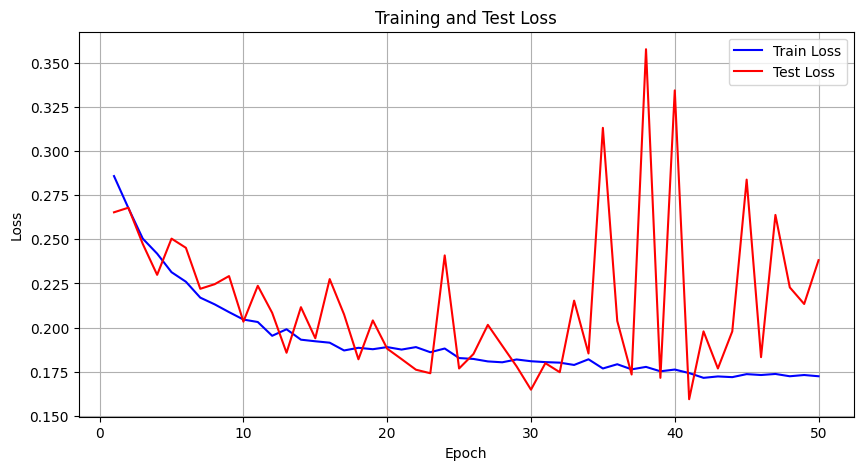

In [104]:
plt.figure(figsize=(10, 5))

plt.plot(epochs, train_losses, label="Train Loss", c="blue")
plt.plot(epochs, test_losses, label="Test Loss", c="red")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")

plt.legend()
plt.grid()
plt.show()

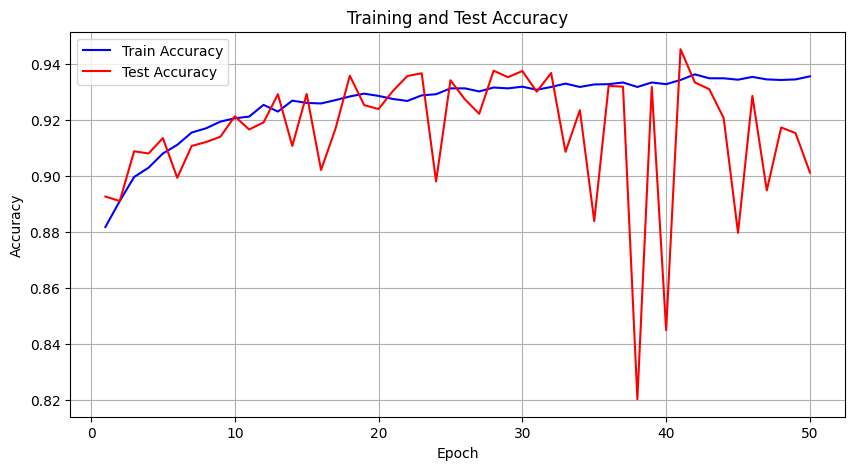

In [105]:
plt.figure(figsize=(10, 5))

plt.plot(epochs, train_accs, label="Train Accuracy", c="blue")
plt.plot(epochs, test_accs, label="Test Accuracy", c="red")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")

plt.legend()
plt.grid()
plt.show()

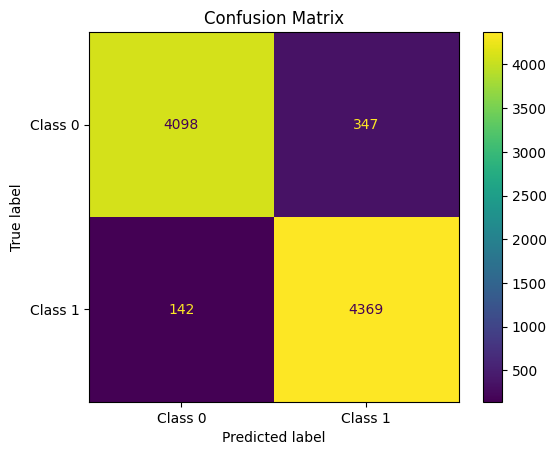

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

# Load best model
model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images).squeeze(1)

        predictions = (outputs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


# Confusion Matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()